In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

from astropy.cosmology import Planck15
DEFAULT_H0 = 67.9
DEFAULT_OM0 = 0.3065
cosmo = Planck15.clone(H0=DEFAULT_H0, Om0=DEFAULT_OM0)

from astropy.io import fits
from astropy.table import Table
import pandas as pd
from scipy.optimize import curve_fit
import tqdm

import matplotlib as mpl

def make_nice_plots():
    SMALL_SIZE = 10 * 2 
    MEDIUM_SIZE = 12 * 2
    BIGGER_SIZE = 14 * 2

    plt.rc('text', usetex=True)
    plt.rc('axes', titlesize=SMALL_SIZE)
    plt.rc('axes', labelsize=MEDIUM_SIZE)
    plt.rc('xtick', labelsize=SMALL_SIZE, direction='out')
    plt.rc('ytick', labelsize=SMALL_SIZE, direction='out')
    plt.rc('legend', fontsize=SMALL_SIZE)
    mpl.rcParams['axes.titlesize'] = BIGGER_SIZE
    mpl.rcParams['ytick.direction'] = 'in'
    mpl.rcParams['xtick.direction'] = 'in'
    mpl.rcParams['mathtext.fontset'] = 'cm'
    mpl.rcParams['font.family'] = 'STIXgeneral'

    mpl.rcParams['figure.dpi'] = 100

    mpl.rcParams['xtick.minor.visible'] = True
    mpl.rcParams['ytick.minor.visible'] = True
    mpl.rcParams['xtick.top'] = True
    mpl.rcParams['ytick.right'] = True

    mpl.rcParams['xtick.major.size'] = 10
    mpl.rcParams['ytick.major.size'] = 10
    mpl.rcParams['xtick.minor.size'] = 4
    mpl.rcParams['ytick.minor.size'] = 4

    mpl.rcParams['xtick.major.width'] = 1.25
    mpl.rcParams['ytick.major.width'] = 1.25
    mpl.rcParams['xtick.minor.width'] = 1
    mpl.rcParams['ytick.minor.width'] = 1

def sigfig_str(x, sig=2):
    if x == 0:
        return "0"
    from decimal import Decimal
    d = Decimal(str(x))
    exponent = d.adjusted()  # position of most significant digit
    decimals = sig - 1 - exponent
    if decimals < 0:
        decimals = 0
    return f"{x:.{decimals}f}"

make_nice_plots()


In [2]:
quaia_new = pd.read_csv('/home/lucas/Documents/PhD/agn_data/quaia_zleq3_withlumcorr.csv')
# quaia_new = pd.read_csv('/home/lucas/Documents/PhD/agn_data/Quaia_z15.csv')

print(np.sum(abs(quaia_new['b']) > 10))

import json, h5py
reweight_PE_json_outpath = '/home/lucas/Documents/PhD/gw_data/reweighted-gwtc5/real_PEsamples_reweight_gwtc5.json'

PE_JSON_PATH = reweight_PE_json_outpath
with open(PE_JSON_PATH, "r") as f:
    gw_path_dict = json.load(f)
gw_keys = list(gw_path_dict.keys())

redshift_dict = {}
redshift_list = []

log10_redshift_dict = {}
log10_redshift_list = []
for key in gw_keys:
    filename = gw_path_dict[key]
    
    with h5py.File(filename, 'r') as PEsamples:
        approx = list(PEsamples.keys())[0]
        data = PEsamples[approx]

        z = data['posterior_samples']['redshift']
        log10_z = np.log10(data['posterior_samples']['redshift'])

        redshift = np.median(z)
        redshift_lower = np.quantile(z, 0.16) - redshift
        redshift_upper = np.quantile(z, 0.84) - redshift
        del z

        log10_redshift = np.median(log10_z)
        log10_redshift_lower = np.quantile(log10_z, 0.16) - log10_redshift
        log10_redshift_upper = np.quantile(log10_z, 0.84) - log10_redshift
        del log10_z
    
    dat = np.array([redshift, redshift_upper, redshift_lower])
    redshift_dict[key] = dat
    redshift_list.append(redshift)
    print(key, 'redshift', redshift_dict[key])  
    
    log10_dat = np.array([log10_redshift, log10_redshift_upper, log10_redshift_lower])
    log10_redshift_dict[key] = log10_dat
    log10_redshift_list.append(log10_redshift)
    

1243157
GW190828_065509 redshift [ 0.30332496  0.07022725 -0.07327242]
GW190630_185205 redshift [ 0.16881091  0.06478128 -0.04220389]
GW170104_101158 redshift [ 0.21421091  0.04288833 -0.05324162]
GW190527_092055 redshift [ 0.48567704  0.16229023 -0.13959287]
GW190929_012149 redshift [ 0.77996313  0.26896506 -0.2395912 ]
GW190924_021846 redshift [ 0.10697894  0.02678741 -0.02863499]
GW190828_063405 redshift [ 0.38137609  0.06045655 -0.09202412]
GW151226_033853 redshift [ 0.0979378   0.02250241 -0.02526579]
GW190412_053044 redshift [ 0.14060033  0.01997767 -0.02073005]
GW170608_020116 redshift [ 0.07004321  0.01592621 -0.01517225]
GW190413_134308 redshift [ 0.8122935   0.14949486 -0.17499396]
GW190910_112807 redshift [ 0.37343737  0.08571708 -0.1041974 ]
GW190602_175927 redshift [ 0.5844352   0.1583005  -0.14210132]
GW190725_174728 redshift [ 0.19732512  0.05224629 -0.05009824]
GW190521_030229 redshift [ 0.78577555  0.1477408  -0.22123358]
GW190708_232457 redshift [ 0.19000719  0.033232

In [3]:
COLORS = ['orangered', 'navy', 'teal', 'goldenrod', 'hotpink', 'indigo', 'crimson']

def get_run(key):
    date = key.split('_')[0][2:]
    y, m, d = int(date[:2]), int(date[2:4]), int(date[4:])
    
    if y < 16:
        run = 'O1'
    elif y < 18:
        run = 'O2'
    elif y < 22:
        run = 'O3'
    else:
        run = 'O4'
    return run


def run2color(run):
    if run == 'O1':
        color = 'blue'
        marker = 'X'
        zorder = 13
    elif run == 'O2':
        color = 'skyblue'
        marker = '^'
        zorder = 12
    elif run == 'O3':
        color = 'limegreen'
        marker = '*'
        zorder = 11
    elif run == 'O4':
        color = 'orangered'
        marker = '.'
        zorder = 10
    return color, marker, zorder

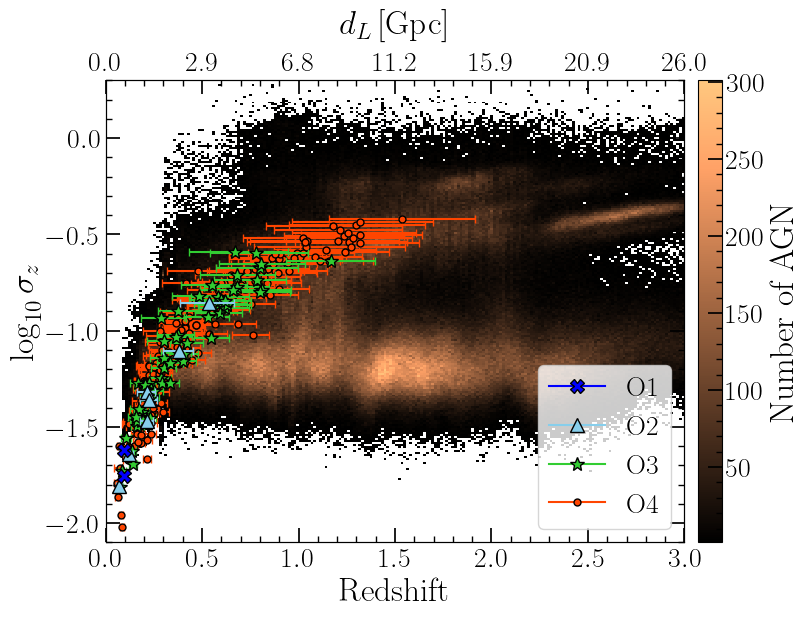

In [4]:
fig, ax = plt.subplots(figsize=(9,6))

z = np.array([redshift_dict[k][0] for k in gw_keys])
zerr_lower = np.array( np.abs([redshift_dict[k][2] for k in gw_keys]) )
zerr_upper = np.array( [redshift_dict[k][1] for k in gw_keys] )

for i, key in enumerate(gw_keys):
    run = get_run(key)
    color, marker, zorder = run2color(run)
    ax.errorbar(
        z[i],
        np.log10( (zerr_lower + zerr_upper)[i] / 2 ),
        xerr=[[zerr_lower[i]], [zerr_upper[i]]],
        marker=marker,
        zorder=zorder,
        markersize=10,
        markeredgecolor='black',
        capsize=3,
        color=color,
        alpha=1
    )

h = ax.hist2d(
                quaia_new['redshift_quaia'],
                np.log10( quaia_new['redshift_quaia_err'] ),
                bins=200,
                cmin=1,
                cmap='copper',
                label='Quaia'
            )

cbar = fig.colorbar(h[3], ax=ax, pad=0.02)
cbar.set_label('Number of AGN')

# ax.plot(np.linspace(0, 3, 100), np.log10(np.linspace(1e-10, 3, 100)), zorder=10, linestyle='dashed', color='grey', alpha=1, linewidth=3)

ax.set_xlabel('Redshift')
ax.set_ylabel(r'$\log_{10} \sigma_{z}$')

# Top axis
upperax1 = ax.twiny()
upperticks = np.array(np.arange(0, 3.1, 0.5))
upperax1.set_xticks(upperticks)
upperax1.set_xticklabels([
    np.around(cosmo.luminosity_distance(z).to(u.Gpc).value, 1)
    for z in upperticks
])
upperax1.set_xlabel(r'$d_L \, [\mathrm{Gpc}]$', labelpad=12, fontsize=24)
ax.set_xlim(0, 3)
upperax1.set_xlim(0, 3)
ax.set_ylim(-2.1, 0.3)

legend_handles = []
for run in ['O1', 'O2', 'O3', 'O4']:
    color, marker, _ = run2color(run)

    legend_handles.append(mpl.lines.Line2D([0], [0],
                                            marker=marker,
                                            linestyle='-',
                                            linewidth=1.5,
                                            color=color,
                                            markerfacecolor=color,
                                            markeredgecolor='black',
                                            markeredgewidth=1,
                                            markersize=10,
                                            label=run))

ax.legend(handles=legend_handles, loc='lower right')

plt.show()


In [ ]:
### load stuff ###
with fits.open('/home/lucas/Documents/PhD/agn_data/quaia_G20.5.fits') as hdul:
# with fits.open('/Users/niccoloveronesi/Downloads/quaia_G20.5.fits') as hdul:
   hdul.verify('fix')

   # print(repr(hdul[1].header))
   data = hdul[1].data
   tab = Table(hdul[1].data)
   quaia_Gmag = data['phot_rp_mean_mag']
   quaia_redshift = data['redshift_quaia']
   quaia_lumdist = cosmo.luminosity_distance(quaia_redshift)

### convert lumdist into cm ###
quaia_lumdist_cm = quaia_lumdist.to(u.cm).value


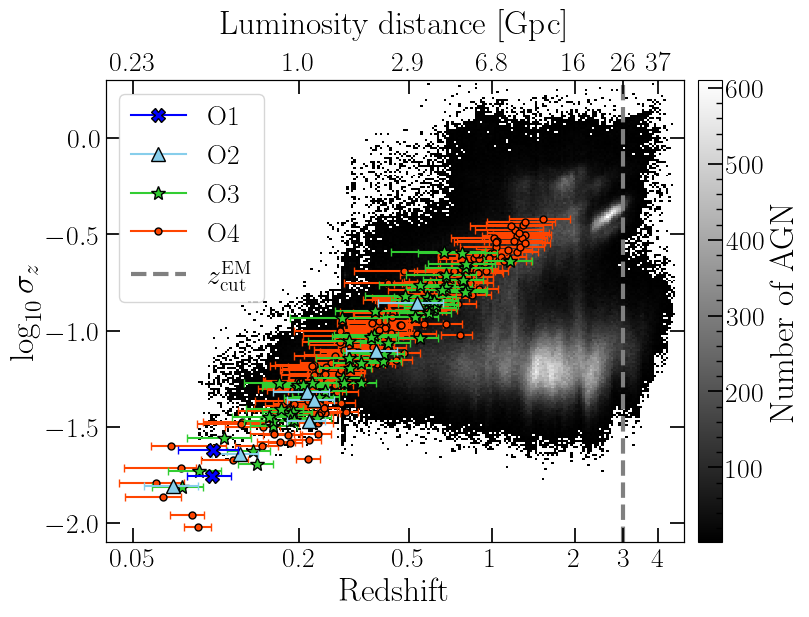

In [6]:
fig, ax = plt.subplots(figsize=(9,6))

z = np.array([log10_redshift_dict[k][0] for k in gw_keys])
log10_zerr_lower = np.array( np.abs([log10_redshift_dict[k][2] for k in gw_keys]) )
log10_zerr_upper = np.array( [log10_redshift_dict[k][1] for k in gw_keys] )

for i, key in enumerate(gw_keys):
    run = get_run(key)
    color, marker, zorder = run2color(run)
    ax.errorbar(
        z[i],
        np.log10( (zerr_lower + zerr_upper)[i] / 2 ),
        xerr=[[log10_zerr_lower[i]], [log10_zerr_upper[i]]],
        marker=marker,
        zorder=zorder,
        markersize=10,
        markeredgecolor='black',
        capsize=3,
        color=color,
        alpha=1
    )

# h = ax.hist2d(
#                 np.log10( quaia_new['redshift_quaia'] ),
#                 np.log10( quaia_new['redshift_quaia_err'] ),
#                 bins=200,
#                 cmin=1,
#                 cmap='grey',
#                 label='Quaia'
#             )
h = ax.hist2d(
                np.log10( data['redshift_quaia'] ),
                np.log10( data['redshift_quaia_err'] ),
                bins=200,
                cmin=1,
                cmap='grey',
                label='Quaia'
            )
h[3].set_rasterized(True)

cbar = fig.colorbar(h[3], ax=ax, pad=0.02)
cbar.set_label('Number of AGN')

ax.vlines(np.log10(3), -2.1, 0.3, label=r'$z_{\rm cut}^{\rm EM}$', linewidth=3, linestyles='dashed', color='gray', zorder=1)

# ax.plot(np.log10(np.linspace(1e-10, 3, 100)), np.log10(np.linspace(1e-10, 3, 100)), zorder=10, linestyle='dashed', color='grey', alpha=1, linewidth=3)

# Top axis

upperax1 = ax.twiny()
upperticks = np.array([0.05, 0.2, 0.5, 1, 2, 3, 4])
upperax1.set_xlim(-1.4, np.log10(5))
upperax1.set_xticks(np.log10(upperticks))

dl_values = cosmo.luminosity_distance(upperticks).to(u.Gpc).value
labels = [sigfig_str(v, 2) for v in dl_values]

upperax1.set_xticklabels(labels)

# upperax1.set_xticklabels([f'{x:.0f}' for x in cosmo.luminosity_distance(upperticks).to(u.Gpc).value])
upperax1.set_xlabel(r'Luminosity distance [Gpc]', labelpad=12, fontsize=24)
ax.set_xlim(-1.4, np.log10(5))
upperax1.set_xlim(-1.4, np.log10(5))

ax.set_ylim(-2.1, 0.3)
# ax.set_xlabel(r'$\log_{10} z$')
ax.set_xlabel('Redshift')
ax.set_ylabel(r'$\log_{10} \sigma_{z}$')

legend_handles = []
for run in ['O1', 'O2', 'O3', 'O4']:
    color, marker, _ = run2color(run)

    legend_handles.append(mpl.lines.Line2D([0], [0],
                                            marker=marker,
                                            linestyle='-',
                                            linewidth=1.5,
                                            color=color,
                                            markerfacecolor=color,
                                            markeredgecolor='black',
                                            markeredgewidth=1,
                                            markersize=10,
                                            label=run))
    

legend_handles.append(mpl.lines.Line2D([0], [0], linewidth=3, linestyle='dashed', label=r'$z_{\rm cut}^{\rm EM}$', color='gray'))

ax.legend(handles=legend_handles, loc='upper left')
# ax.grid(alpha=0.2)

ticks = upperticks
ax.minorticks_off()
upperax1.minorticks_off()
ax.set_xticks(np.log10(ticks))
ax.set_xticklabels([sigfig_str(v, 1) for v in upperticks])

# def flatten(xss):
#     return [x for xs in xss for x in xs]

# minor_ticks = flatten( [list(np.linspace(ticks[i], ticks[i+1], 7)) for i in range(len(ticks) - 1)] )
# print(minor_ticks)
# minor_ticks = minor_ticks[~np.isin(minor_ticks, ticks)]

# ax.set_xticks(np.log10(minor_ticks), minor=True)
# plt.savefig('/home/lucas/Documents/PhD/darksirenpop/p26plots_v2/quaia_plus_gws.pdf', bbox_inches='tight')

plt.show()


In [7]:
### calculate flux in electrons per second ###
ZP = 24.7479
C_NU = 3.298815E-33

# ZP = 25.6874
# C_NU = 1.736011E-33

f_elecpersec=10**(-(quaia_Gmag-ZP)/2.5)

### convert to erg/(s*cm^2*Hz)###
log10_f_ergscm2Hz = np.log10(f_elecpersec) + np.log10(C_NU) + 3

In [8]:
### calculate shape of SED in the frequency range we are interested in ###
### observed frequency: 10^14.588 Hz
### maximum emitted frequency = (1+z_max)*observed_frequency = 4*observed frequency
log_nu_max=np.log10(4*(10**14.588))
print('The log of the maximum emitted frequency is ',np.round(log_nu_max,3))
### x and y (in the following lines) have been obtained with webplotdigitizer from Figure 11 of
### https://iopscience.iop.org/article/10.1086/506525/pdf

x=[14.586,15.191]
y=[45.315,45.692]
slope=(y[1]-y[0])/(x[1]-x[0])
print('The spectral index of the SED in the frequency range we are interested is ', np.round(slope, 3))
### the value of "slope" has to be compared with what you have in the last term of Eq. 2 of Veronesi+25 (they are very similar)

The log of the maximum emitted frequency is  15.19
The spectral index of the SED in the frequency range we are interested is  0.623


In [9]:
### calculate band luminosity ###
log10_bandlum = 14.588 + log10_f_ergscm2Hz + np.log10(4 * np.pi) + 2 * np.log10(quaia_lumdist_cm) + (-1 * slope) * np.log10(1 + quaia_redshift)
# bandlum=(10**14.588)*f_ergscm2Hz*(4*np.pi*quaia_lumdist_cm**2)*(1+quaia_redshift)**(-1*slope)
### calculate bolometric luminosity ###
log10_bollum = log10_bandlum + np.log10(11.004)

### Save Quaia with added column (bolometric luminosity ###
tab['log10_bollum'] = log10_bollum
# tab.write('/Users/niccoloveronesi/Desktop/quaia_G20.5_withbollum.fits',overwrite=True)

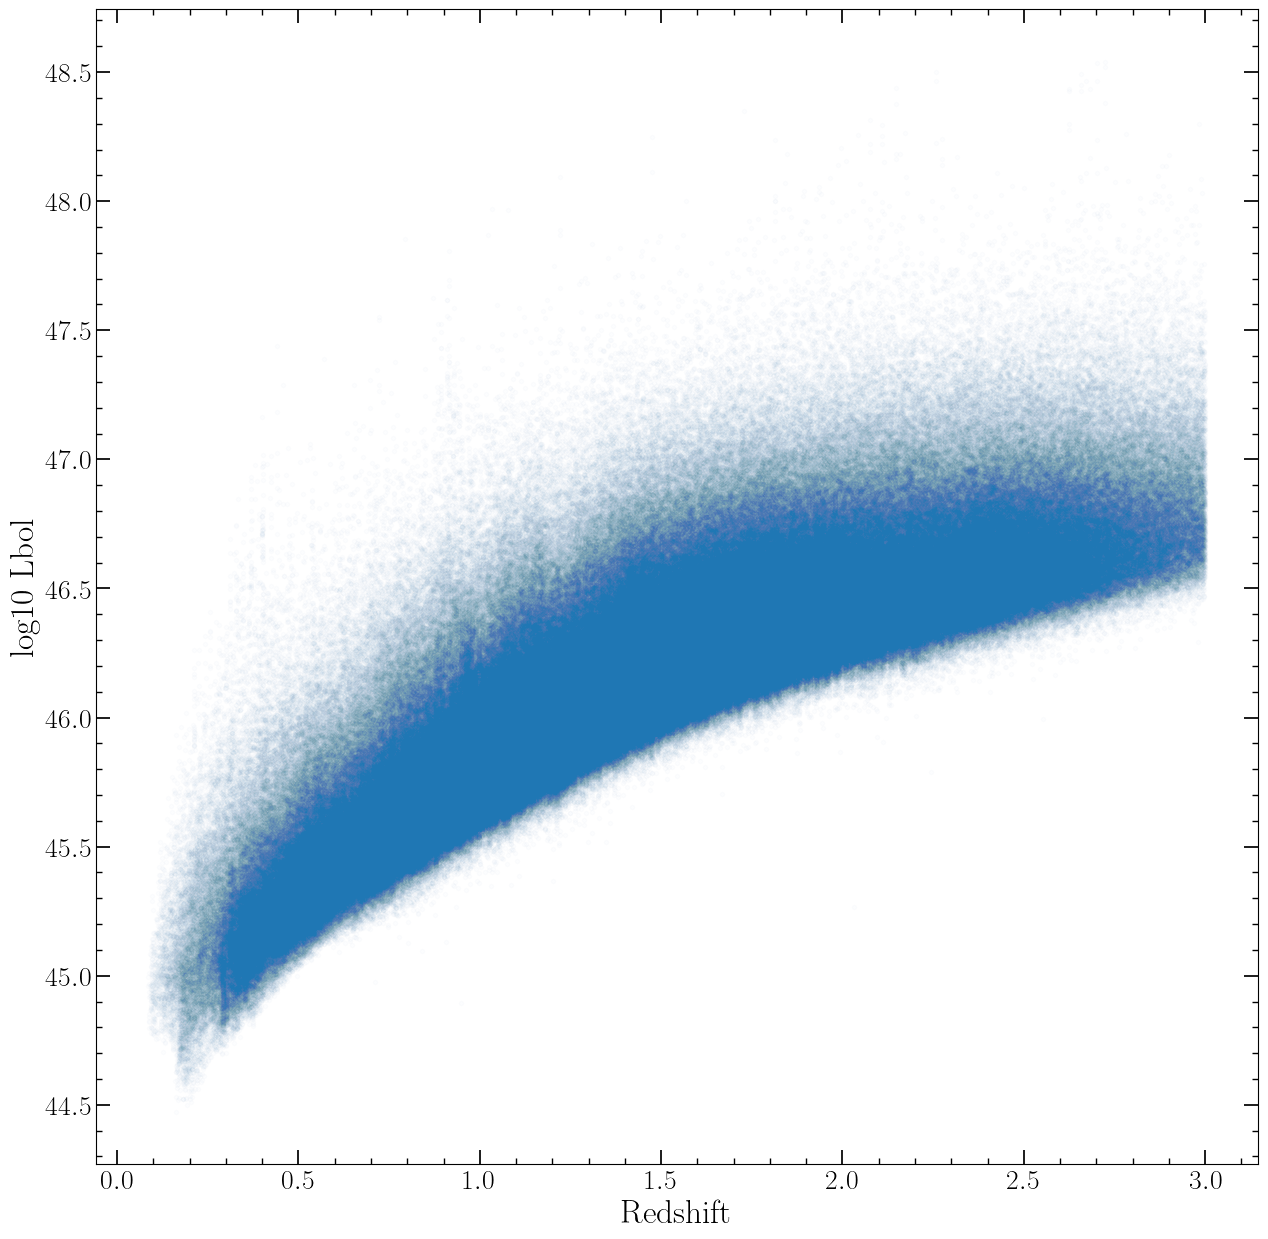

In [10]:
### Plot the luminosities obtained from Quaia ###
plt.figure(figsize=(15,15))
plt.scatter(quaia_redshift[quaia_redshift < 3], log10_bollum[quaia_redshift < 3], marker='.', alpha=0.01)
# plt.loglog()
plt.xlabel('Redshift')
plt.ylabel('log10 Lbol')
plt.show()

725


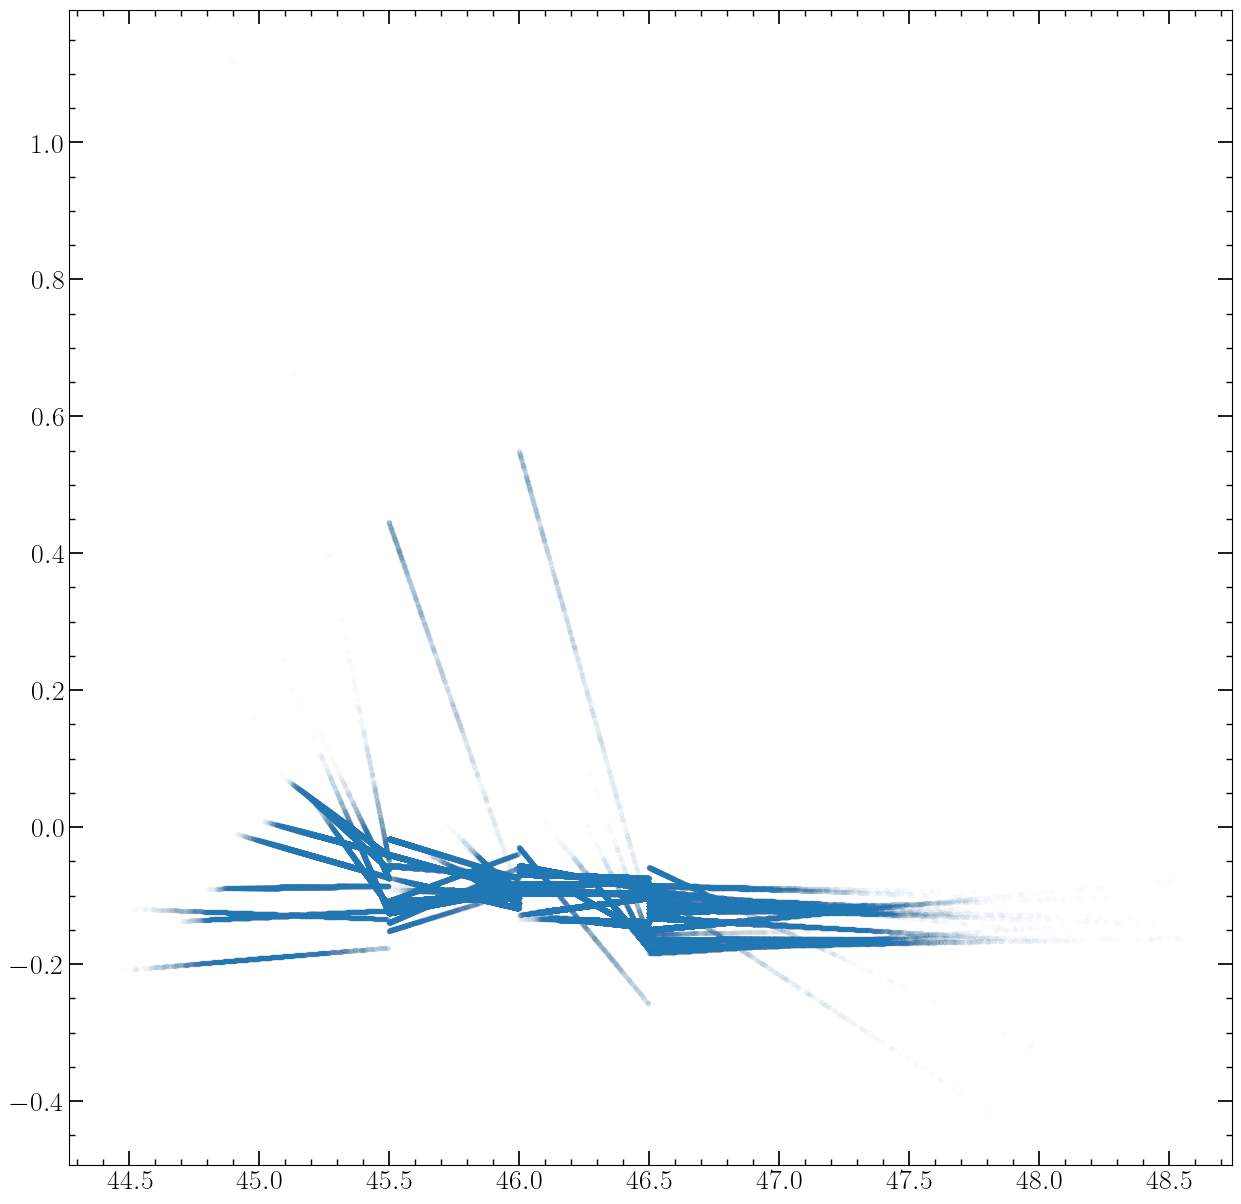

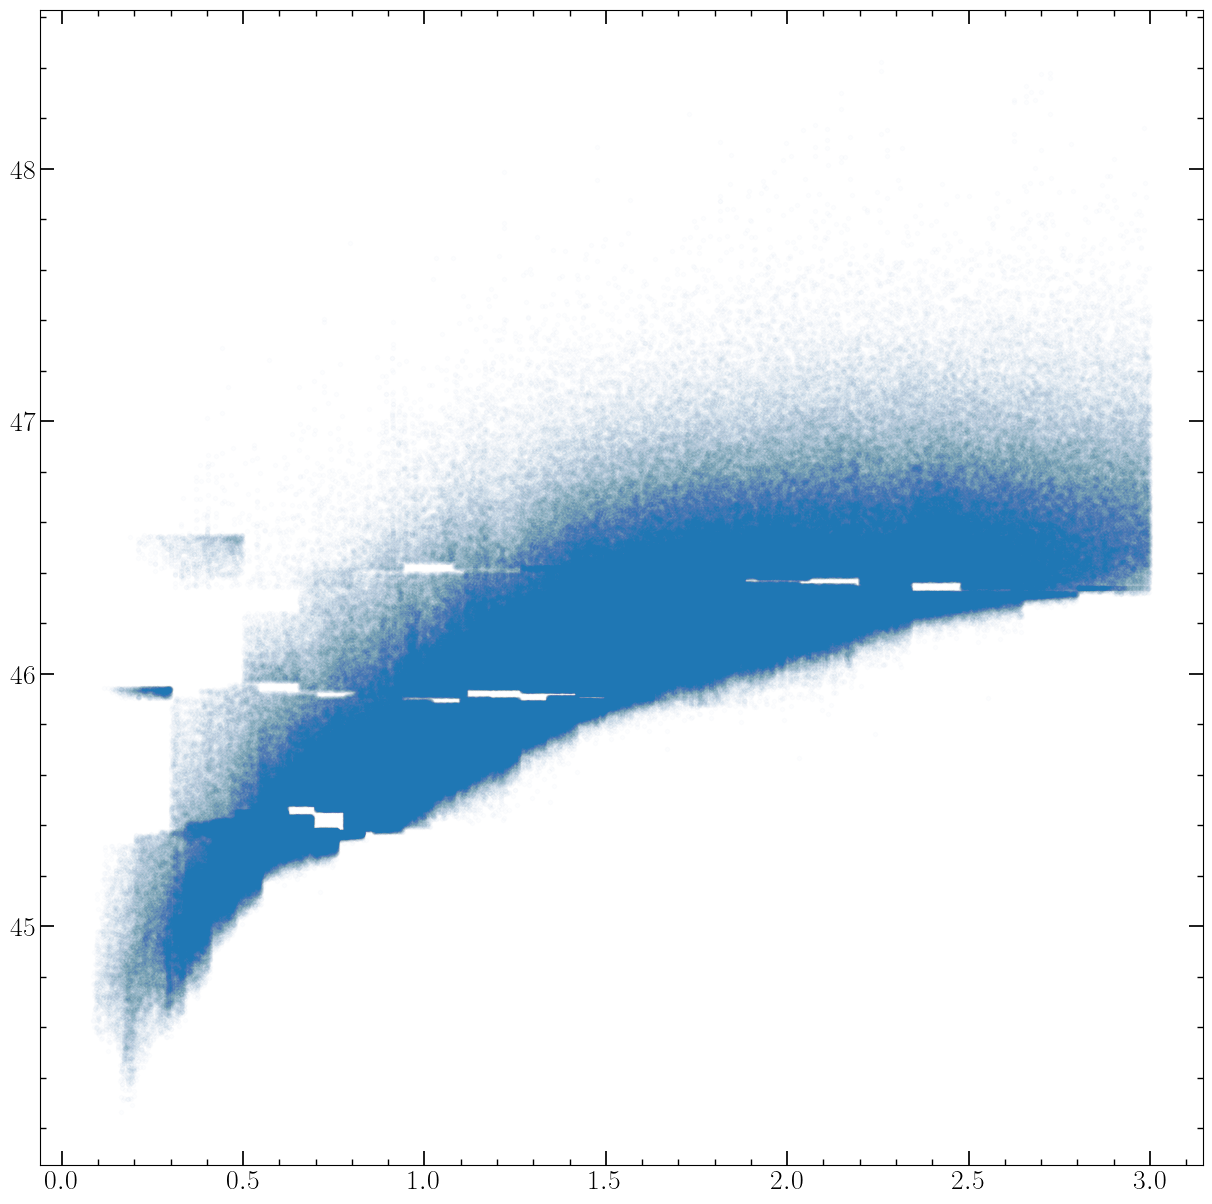

In [28]:
quaia_corr_new = pd.read_csv('/home/lucas/Documents/PhD/agn_data/quaia_zleq3_withlumcorr.csv')
log10bol_corr = quaia_corr_new['loglbol_corr']
z_corr = quaia_corr_new['redshift_quaia']
print(np.sum((log10bol_corr > 46.5) & (z_corr < 0.6)))

plt.figure(figsize=(15,15))
plt.scatter(log10_bollum[quaia_redshift < 3], log10bol_corr[z_corr < 3] - log10_bollum[quaia_redshift < 3], marker='.', alpha=0.01)
plt.show()

plt.figure(figsize=(15,15))
plt.scatter(z_corr, log10bol_corr, marker='.', alpha=0.01)
plt.show()


In [7]:
# plt.figure()
# plt.scatter(np.arange(len(log10_bollum)), log10_bollum_1 - log10_bollum, marker='.', alpha=1)
# # plt.loglog()
# plt.xlabel('Redshift')
# plt.ylabel('log10 Lbol')
# plt.show()

In [8]:
def linearfit(x,m,q):
    return m*x+q

In [9]:
### Perform linear fits to correct according to wushen22 ###
cat_leq455=pd.read_csv('/Users/niccoloveronesi/Desktop/quaiawu_zleq3_leq455.csv')
params_leq455,cov_leq455=curve_fit(linearfit,cat_leq455['log10_bollum'],cat_leq455['LOGLBOL'])
intr_scatt_leq455=np.std(cat_leq455['LOGLBOL']-(cat_leq455['log10_bollum']*params_leq455[0]+params_leq455[1]))
print('Bolometric luminosities <=45.5; slope=',np.round(params_leq455[0],3),', intercept=', np.round(params_leq455[1],3),
      ', intrinsic scatter=',np.round(intr_scatt_leq455,3))

cat_455to46=pd.read_csv('/Users/niccoloveronesi/Desktop/quaiawu_zleq3_455to46.csv')
params_455to46,cov_455to46=curve_fit(linearfit,cat_455to46['log10_bollum'],cat_455to46['LOGLBOL'])
intr_scatt_455to46=np.std(cat_455to46['LOGLBOL']-(cat_455to46['log10_bollum']*params_455to46[0]+params_455to46[1]))
print('Bolometric luminosities >45.5 and <=46; slope=',np.round(params_455to46[0],3),', intercept=', np.round(params_455to46[1],3),
      ', intrinsic scatter=',np.round(intr_scatt_455to46,3))

cat_46to465=pd.read_csv('/Users/niccoloveronesi/Desktop/quaiawu_zleq3_46to465.csv')
params_46to465,cov_46to465=curve_fit(linearfit,cat_46to465['log10_bollum'],cat_46to465['LOGLBOL'])
intr_scatt_46to465=np.std(cat_46to465['LOGLBOL']-(cat_46to465['log10_bollum']*params_46to465[0]+params_46to465[1]))
print('Bolometric luminosities >46 and <=46.5; slope=',np.round(params_46to465[0],3),', intercept=', np.round(params_46to465[1],3),
      ', intrinsic scatter=',np.round(intr_scatt_46to465,3))

cat_g465=pd.read_csv('/Users/niccoloveronesi/Desktop/quaiawu_zleq3_g465.csv')
params_g465,cov_g465=curve_fit(linearfit,cat_g465['log10_bollum'],cat_g465['LOGLBOL'])
intr_scatt_g465=np.std(cat_g465['LOGLBOL']-(cat_g465['log10_bollum']*params_g465[0]+params_g465[1]))
print('Bolometric luminosities >=46.5; slope=',np.round(params_g465[0],3),', intercept=', np.round(params_g465[1],3),
      ', intrinsic scatter=',np.round(intr_scatt_g465,3))

Bolometric luminosities <=45.5; slope= 1.031 , intercept= -1.468 , intrinsic scatter= 0.405
Bolometric luminosities >45.5 and <=46; slope= 1.004 , intercept= -0.262 , intrinsic scatter= 0.295
Bolometric luminosities >46 and <=46.5; slope= 0.906 , intercept= 4.227 , intrinsic scatter= 0.414
Bolometric luminosities >=46.5; slope= 0.983 , intercept= 0.639 , intrinsic scatter= 0.496


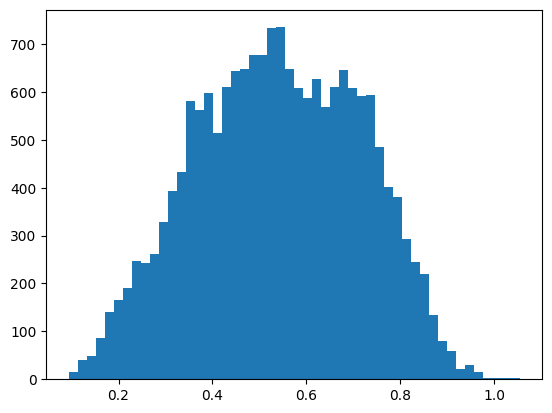

N=417
N=796
N=1268
N=2070
N=2270
N=2563
N=2307
N=2221
N=2101
N=1302
N=588
N=136


In [10]:
### Perform linear fits to correct according to wushen22 (with redshift bins) ###
plt.hist(cat_leq455['redshift_quaia'],bins=50)
plt.show()
zmin=0.2
zmax=0.9
nbins=10
z_edges=np.linspace(zmin,zmax,nbins+1)
all_edges=np.concatenate(([-np.inf],z_edges,[np.inf]))
slopes_leq455=[]
interc_leq455=[]
z=np.array(cat_leq455['redshift_quaia'])
bollum_quaia=np.array(cat_leq455['log10_bollum'])
bollum_wushen=np.array(cat_leq455['LOGLBOL'])
for i in range(len(all_edges)-1):
    z_low=all_edges[i]
    z_high=all_edges[i+1]
    mask=(z>z_low)&(z<=z_high)
    print(f'N={mask.sum()}')
    params,cov=curve_fit(linearfit,bollum_quaia[mask],bollum_wushen[mask])
    slopes_leq455.append(params[0])
    interc_leq455.append(params[1])

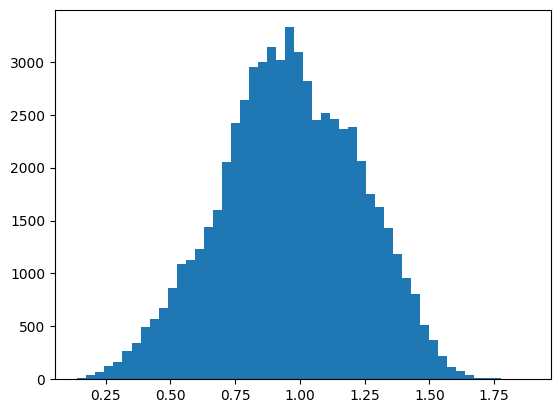

N=319
N=652
N=1213
N=1885
N=2664
N=3468
N=5252
N=6683
N=7078
N=7230
N=5968
N=5621
N=5044
N=3815
N=2640
N=1591
N=833


In [12]:
plt.hist(cat_455to46['redshift_quaia'],bins=50)
plt.show()
zmin=0.3
zmax=1.5
nbins=15
z_edges = np.linspace(zmin,zmax,nbins+1)
all_edges = np.concatenate(([-np.inf],z_edges,[np.inf]))
slopes_455to46=[]
interc_455to46=[]
z=np.array(cat_455to46['redshift_quaia'])
bollum_quaia=np.array(cat_455to46['log10_bollum'])
bollum_wushen=np.array(cat_455to46['LOGLBOL'])
for i in range(len(all_edges)-1):
    z_low=all_edges[i]
    z_high=all_edges[i+1]
    mask=(z>z_low)&(z<=z_high)
    print(f'N={mask.sum()}')
    params,cov=curve_fit(linearfit,bollum_quaia[mask],bollum_wushen[mask])
    slopes_455to46.append(params[0])
    interc_455to46.append(params[1])

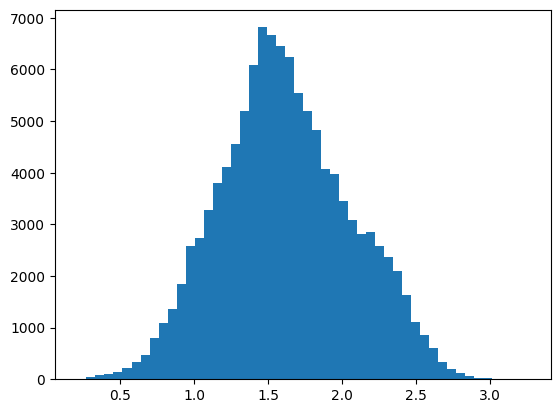

N=310
N=679
N=1995
N=4119
N=7218
N=9964
N=13397
N=16801
N=15190
N=12515
N=9507
N=7415
N=6487
N=4415
N=2011
N=631
N=190


In [13]:
plt.hist(cat_46to465['redshift_quaia'],bins=50)
plt.show()
zmin=0.5
zmax=2.8
nbins=15
z_edges=np.linspace(zmin,zmax,nbins+1)
all_edges=np.concatenate(([-np.inf],z_edges,[np.inf]))
slopes_46to465=[]
interc_46to465=[]
z=np.array(cat_46to465['redshift_quaia'])
bollum_quaia=np.array(cat_46to465['log10_bollum'])
bollum_wushen=np.array(cat_46to465['LOGLBOL'])
for i in range(len(all_edges)-1):
    z_low=all_edges[i]
    z_high=all_edges[i+1]
    mask=(z>z_low)&(z<=z_high)
    print(f'N={mask.sum()}')
    params,cov=curve_fit(linearfit,bollum_quaia[mask],bollum_wushen[mask])
    slopes_46to465.append(params[0])
    interc_46to465.append(params[1])

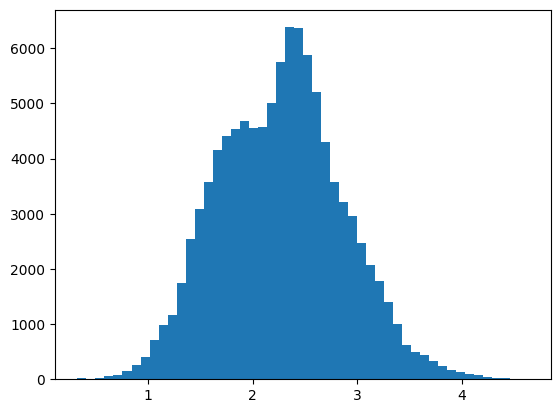

N=261
N=400
N=885
N=1566
N=2530
N=4476
N=5713
N=7077
N=7341
N=7549
N=7619
N=9435
N=10430
N=9154
N=7075
N=5481
N=14767


In [14]:
plt.hist(cat_g465['redshift_quaia'],bins=50)
plt.show()
zmin=0.8
zmax=2.9
nbins=15
z_edges=np.linspace(zmin,zmax,nbins+1)
all_edges=np.concatenate(([-np.inf],z_edges,[np.inf]))
slopes_g465=[]
interc_g465=[]
z=np.array(cat_g465['redshift_quaia'])
bollum_quaia=np.array(cat_g465['log10_bollum'])
bollum_wushen=np.array(cat_g465['LOGLBOL'])
for i in range(len(all_edges)-1):
    z_low=all_edges[i]
    z_high=all_edges[i+1]
    mask=(z>z_low)&(z<=z_high)
    print(f'N={mask.sum()}')
    params,cov=curve_fit(linearfit,bollum_quaia[mask],bollum_wushen[mask])
    slopes_g465.append(params[0])
    interc_g465.append(params[1])

In [17]:
quaia=pd.read_csv('/Users/niccoloveronesi/Desktop/quaia_zleq3.csv')
bollum=quaia['log10_bollum'].to_numpy()
z=quaia['redshift_quaia'].to_numpy()
bollum_corr = np.empty_like(bollum)

z_edges_leq455 = np.linspace(0.2, 0.9, 11)
z_edges_455to46 = np.linspace(0.3, 1.5, 16)
z_edges_46to465 = np.linspace(0.5, 2.8, 16)
z_edges_g465 = np.linspace(0.8, 2.9, 16)

zmin1=0.2
zmax1=0.9
nbins1=10
z_edges1=np.linspace(zmin1,zmax1,nbins1+1)
all_edges1=np.concatenate(([-np.inf],z_edges1,[np.inf]))

zmin2=0.3
zmax2=1.5
nbins2=15
z_edges2=np.linspace(zmin2,zmax2,nbins2+1)
all_edges2=np.concatenate(([-np.inf],z_edges2,[np.inf]))

zmin3=0.5
zmax3=2.8
nbins3=15
z_edges3=np.linspace(zmin3,zmax3,nbins3+1)
all_edges3=np.concatenate(([-np.inf],z_edges3,[np.inf]))

zmin4=0.8
zmax4=2.9
nbins4=15
z_edges4=np.linspace(zmin4,zmax4,nbins4+1)
all_edges4=np.concatenate(([-np.inf],z_edges4,[np.inf]))

for i in tqdm.tqdm(range(len(quaia))):
    if bollum[i]<=45.5:
        z_idx=np.digitize(z[i],all_edges1)-1
        bollum_corr[i]=slopes_leq455[z_idx]*bollum[i]+interc_leq455[z_idx]
    if (bollum[i]>45.5)&(bollum[i]<=46):        
        z_idx=np.digitize(z[i],z_edges2)-1
        bollum_corr[i]=slopes_455to46[z_idx]*bollum[i]+interc_455to46[z_idx]
    if (bollum[i]>46)&(bollum[i]<=46.5):        
        z_idx=np.digitize(z[i],z_edges3)-1
        bollum_corr[i]=slopes_46to465[z_idx]*bollum[i]+interc_46to465[z_idx]
    if np.array(bollum)[i]>46.5:        
        z_idx=np.digitize(z[i],z_edges4)-1
        bollum_corr[i]=slopes_g465[z_idx]*bollum[i]+interc_g465[z_idx]

100%|███████████████████████████████| 1259043/1259043 [14:43<00:00, 1425.41it/s]


In [19]:
quaia['bollum_corr']=bollum_corr
quaia.to_csv('/Users/niccoloveronesi/Desktop/quaia_zleq3_withlumcorr.csv')